In [3]:

import pandas as pd

titanic_df = pd.read_csv(r"clean_titanic_dataset.csv")

titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials
0,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,0,S,Mr
1,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,1,C,Mrs
2,1.0,3.0,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,0,S,Miss
3,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,1,S,Mrs
4,0.0,3.0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,0,S,Mr


DATA ENCODING

In [4]:
titanic_df.Sex

0        male
1      female
2      female
3      female
4        male
        ...  
869      male
870    female
871    female
872      male
873      male
Name: Sex, Length: 874, dtype: str

ONE-HOT ENCODING

In [5]:
pd.get_dummies(titanic_df, columns=["Sex","Embarked"], dtype=int).head(5)

,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,initials,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.0,3.0,"Braund, Mr. Owen Harris",22.0,1.0,0.0,A/5 21171,7.2500,0,Mr,0,1,0,0,1
1,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1.0,0.0,PC 17599,71.2833,1,Mrs,1,0,1,0,0
2,1.0,3.0,"Heikkinen, Miss. Laina",26.0,0.0,0.0,STON/O2. 3101282,7.9250,0,Miss,1,0,0,0,1
3,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1.0,0.0,113803,53.1000,1,Mrs,1,0,0,0,1
4,0.0,3.0,"Allen, Mr. William Henry",35.0,0.0,0.0,373450,8.0500,0,Mr,0,1,0,0,1


In [6]:
import sklearn
sklearn.show_versions()


System:
    python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
executable: c:\Users\bobs9\OneDrive\Desktop\DS-ML-Project1\.venv\Scripts\python.exe
   machine: Windows-10-10.0.26200-SP0

Python dependencies:
      sklearn: 1.9.0
          pip: 26.2.1
   setuptools: 65.5.0
        numpy: 2.4.6
        scipy: 1.17.1
       Cython: None
       pandas: 3.0.5
   matplotlib: 3.11.1
       joblib: 1.5.3
threadpoolctl: 3.6.0
     narwhals: 2.24.0

Built with OpenMP: True

threadpoolctl info:
       user_api: blas
   internal_api: openblas
    num_threads: 12
         prefix: libscipy_openblas
       filepath: C:\Users\bobs9\OneDrive\Desktop\DS-ML-Project1\.venv\Lib\site-packages\numpy.libs\libscipy_openblas64_-63c857e738469261263c764a36be9436.dll
        version: 0.3.31.188.0
threading_layer: pthreads
   architecture: Haswell

       user_api: openmp
   internal_api: openmp
    num_threads: 12
         prefix: vcomp
       filepath: C:\Users\bobs9\OneDrive

## FEATURE RELATIONSHIP

CORRERELATION

In [7]:
titanic_df.corr(numeric_only=True)

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin
Survived,1.000000,-0.347920,-0.069970,-0.037099,0.088546,0.263656,0.320768
Pclass,-0.347920,1.000000,-0.341088,0.081523,0.024483,-0.549743,-0.722195
Age,-0.069970,-0.341088,1.000000,-0.270776,-0.204454,0.090691,0.232366
SibSp,-0.037099,0.081523,-0.270776,1.000000,0.416264,0.159262,-0.040342
Parch,0.088546,0.024483,-0.204454,0.416264,1.000000,0.197376,0.029055
Fare,0.263656,-0.549743,0.090691,0.159262,0.197376,1.000000,0.478358
Cabin,0.320768,-0.722195,0.232366,-0.040342,0.029055,0.478358,1.000000


<Axes: xlabel='Age', ylabel='Pclass'>

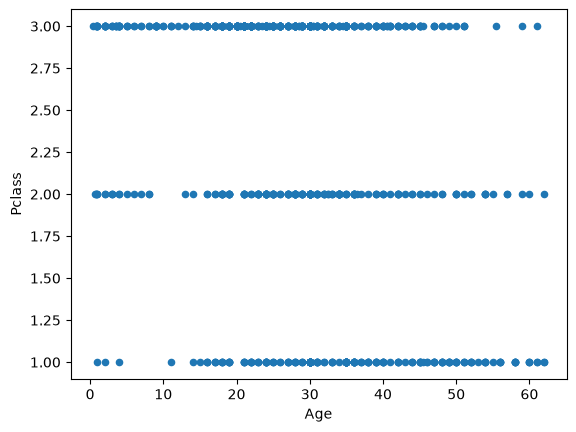

In [8]:
titanic_df[["Age","Pclass"]].plot(kind="scatter", x = "Age",y = "Pclass")

CHI SQUARE

In [9]:
import scipy.stats as stats

In [10]:
contengency_table = pd.crosstab(titanic_df.Pclass, titanic_df.Survived)
contengency_table

Survived,0.0,1.0
Pclass,,
1.0,73,132
2.0,95,87
3.0,369,118


In [11]:
chi2_score, pvalue, dof, excepted_frequency = stats.chi2_contingency(contengency_table)

In [12]:
print(f"Chi-Squared test score = {round(chi2_score, 3)}")
print(f"p-value = {round(pvalue, 5)}")
pvalue < 0.05

Chi-Squared test score = 106.508
p-value = 0.0


np.True_

Interpreting the results

* The chi-square test statistic measures the difference between the observed and expected frequencies. A larger test statistic indicates a larger deviation from the expected frequencies.
* The p-value represents the probability of observing a test statistic as extreme as the one calculated, assuming the null hypothesis is true. A small p-value (typically below a significance level such as 0.05) suggests rejecting the null hypothesis in favor of the alternative hypothesis.
* The expected frequencies are the frequencies that would be expected under the null hypothesis. Comparing the observed frequencies to the expected frequencies provides insights into the association between the categorical variables.

In [13]:
contengency_table = pd.crosstab(titanic_df.SibSp, titanic_df.Cabin)
contengency_table

Cabin,0,1
SibSp,,
0.0,474,120
1.0,140,66
2.0,22,6
3.0,13,3
4.0,18,0
5.0,5,0
8.0,7,0


In [14]:
chi2_score, pvalue, _, _ = stats.chi2_contingency(contengency_table)

In [15]:
print(f"Chi-Squared test score = {round(chi2_score, 3)}")
print(f"p-value = {round(pvalue, 5)}")

Chi-Squared test score = 21.516
p-value = 0.00148
